# Joint Probability Graphs

PyMC relies on PyTensor for its mathematical expressions and array processing. PyTensor also compiles the model into one joint log-probability before sampling takes place. If we think back to Unit 5, this is the target function or un-normalized posterior expression that we are giving to the MCMC sampler. Using the log of that expression is generally preferred for computational stability.

PyTensor actually performs a lot of optimizations automatically to speed up sampling. Things like automatically simplifying the arithmetic to have fewer operations, switching to more numerically stable but equivalent expressions, and computing/storing constants instead of repeatedly calculating them. This all happens away from the user-level.

## Normal-Cauchy model example

This is the model from Unit 5 Lessons 6 and 7. I'm going to define it directly in PyTensor right now to show a printout of what the uncompiled model graph looks like, then the compiled version. I'm also adding in some unnecessary operations to show how they get optimized away. Don't worry too much about the syntax here, we do not need this much of this for PyMC models.

In [ ]:
import pytensor
import pytensor.tensor as pt
from pytensor.printing import debugprint
from pymc.logprob import conditional_logp

# values
theta_value = pt.scalar("theta_value")
x_observed = pt.scalar("x_observed")

# random variables
theta_rv = pt.random.cauchy(0.0, 1.0, name="theta")
mu = -(-theta_rv) + (2.0 * 3.0 - 6.0)  # extra 0 and double negative
x_rv = pt.random.normal(mu, pt.sqrt(1.0), name="x")  # unnecessary sqrt

logp_terms = conditional_logp(
    {
        theta_rv: theta_value,
        x_rv: x_observed,
    }
)
joint_logp = sum(logp_terms.values())

print("Uncompiled graph:")
debugprint(joint_logp)

logp_fn = pytensor.function(
    [theta_value, x_observed],
    joint_logp,
    mode="FAST_RUN",
)

Uncompiled graph:
Add [id A]
 ├─ Add [id B]
 │  ├─ 0 [id C]
 │  └─ Check{beta > 0} [id D] 'theta_value_logprob'
 │     ├─ Sub [id E]
 │     │  ├─ Sub [id F]
 │     │  │  ├─ Neg [id G]
 │     │  │  │  └─ Log [id H]
 │     │  │  │     └─ 3.141592653589793 [id I]
 │     │  │  └─ Log [id J]
 │     │  │     └─ 1.0 [id K]
 │     │  └─ Log1p [id L]
 │     │     └─ Pow [id M]
 │     │        ├─ True_div [id N]
 │     │        │  ├─ Sub [id O]
 │     │        │  │  ├─ theta_value [id P]
 │     │        │  │  └─ 0.0 [id Q]
 │     │        │  └─ 1.0 [id K]
 │     │        └─ 2 [id R]
 │     └─ ScalarFromTensor [id S]
 │        └─ All{axes=None} [id T]
 │           └─ MakeVector{dtype='bool'} [id U]
 │              └─ All{axes=None} [id V]
 │                 └─ Gt [id W]
 │                    ├─ 1.0 [id K]
 │                    └─ 0 [id X]
 └─ Check{sigma > 0} [id Y] 'x_observed_logprob'
    ├─ Sub [id Z]
    │  ├─ Sub [id BA]
    │  │  ├─ Mul [id BB]
    │  │  │  ├─ -0.5 [id BC]
    │  │  │  └─ P

Above is the uncompiled log-probability graph output. Below is the compiled version and an evaluation at theta=0 and the observed x value.

In [24]:
print("\nCompiled graph:")
debugprint(logp_fn.maker.fgraph.outputs[0])

print("\nlogp(theta=0, x=2):", logp_fn(0.0, 2.0))


Compiled graph:
Composite{((-1.1447298858494002 - log1p(sqr(i0))) + -0.9189385332046727 + (-0.5 * sqr((i1 - i0))))} [id A]
 ├─ theta_value [id B]
 └─ x_observed [id C]

Inner graphs:

Composite{((-1.1447298858494002 - log1p(sqr(i0))) + -0.9189385332046727 + (-0.5 * sqr((i1 - i0))))} [id A]
 ← add [id D] 'o0'
    ├─ sub [id E]
    │  ├─ -1.1447298858494002 [id F]
    │  └─ log1p [id G]
    │     └─ sqr [id H]
    │        └─ i0 [id I]
    ├─ -0.9189385332046727 [id J]
    └─ mul [id K]
       ├─ -0.5 [id L]
       └─ sqr [id M]
          └─ sub [id N]
             ├─ i1 [id O]
             └─ i0 [id I]

logp(theta=0, x=2): -4.063668419054073


For Unit 5 Lesson 7, with one datapoint $x=2$, the posterior kernel is

$$
\pi(\theta \mid x) \propto \frac{\exp\!\left(-\frac12 (x-\theta)^2\right)}{1+\theta^2}.
$$

The compiled log-probability output, above, is the log of that same expression, with some extra constants:

$$
-\log(1+\theta^2)\;-\;\frac12(x-\theta)^2\;+\;\text{constant}.
$$

## PyMC model specification

Here is how we would specify this model in PyMC.

In [25]:
import pymc as pm

x_observed = 2.0

with pm.Model() as normal_cauchy_model:
    theta = pm.Cauchy("theta", alpha=0.0, beta=1.0)

    pm.Normal("x", mu=theta, sigma=1, observed=x_observed)

You can see that the model matches the above PyTensor version.

In [26]:
logp_terms = normal_cauchy_model.logp(sum=False)
debugprint(logp_terms)

Check{beta > 0} [id A] 'theta_logprob'
 ├─ Sub [id B]
 │  ├─ Sub [id C]
 │  │  ├─ Neg [id D]
 │  │  │  └─ Log [id E]
 │  │  │     └─ 3.141592653589793 [id F]
 │  │  └─ Log [id G]
 │  │     └─ 1.0 [id H]
 │  └─ Log1p [id I]
 │     └─ Pow [id J]
 │        ├─ True_div [id K]
 │        │  ├─ Sub [id L]
 │        │  │  ├─ theta [id M]
 │        │  │  └─ 0.0 [id N]
 │        │  └─ 1.0 [id H]
 │        └─ 2 [id O]
 └─ ScalarFromTensor [id P]
    └─ All{axes=None} [id Q]
       └─ MakeVector{dtype='bool'} [id R]
          └─ All{axes=None} [id S]
             └─ Gt [id T]
                ├─ 1.0 [id H]
                └─ 0 [id U]
Alloc [id V] 'x_logprob'
 └─ Check{sigma > 0} [id W]
    ├─ Sub [id X]
    │  ├─ Sub [id Y]
    │  │  ├─ Mul [id Z]
    │  │  │  ├─ -0.5 [id BA]
    │  │  │  └─ Pow [id BB]
    │  │  │     ├─ True_div [id BC]
    │  │  │     │  ├─ Sub [id BD]
    │  │  │     │  │  ├─ x{2.0} [id BE]
    │  │  │     │  │  └─ theta [id M]
    │  │  │     │  └─ 1 [id BF]
    │  │  │     └─

This is the theoretical model printed out in plate notation.

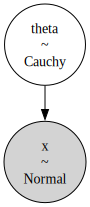

In [27]:
pm.model_to_graphviz(normal_cauchy_model)

Finally, this is how we would sample the model and use a random seed, then look at a summary of the results.

In [ ]:
import numpy as np

rng = np.random.default_rng(6420)

with normal_cauchy_model:
    trace = pm.sample(random_seed=rng)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [29]:
import arviz as az

az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,1.299,0.936,-0.333,3.061,0.023,0.015,1717.0,2097.0,1.0
